Import of libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('medical_examination.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df[df.isnull()].count()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [4]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

Creating an Overweight Indicator Based on BMI

In [12]:
df['bmi'] = df['weight'] / (df['height'] / 100)**2

In [13]:
df['overweight'] = df['bmi'] > 25

In [17]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,False,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,True,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,False,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,True,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,False,23.011177


In [18]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight,bmi
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,True,26.927438
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,True,50.472681
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,True,31.353579
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,True,27.099251
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0,False,24.913495


In [19]:
df['overweight'].unique()

array([False,  True])

1--> Female, 2--> Male, 3-->Other

In [20]:
df['gender'].unique()

array([2, 1, 3])

🧪 **Normalizing Cholesterol & Glucose Risk Indicators**

**Objective**: Convert cholesterol and glucose levels into binary risk indicators for analysis:
- 0 → Good / Normal
- 1 → Elevated / Bad

Normalization Rules:--
- If Cholesterol = 1, convert to → 0
- If Cholesterol > 1, convert to → 1
- If Glucose = 1, convert to → 0
- If Glucose > 1, convert to → 1

In [22]:
df['cholesterol'].unique()

array([1, 3, 2])

In [23]:
df['gluc'].unique()

array([1, 2, 3])

In [24]:
medical_data = {1:0, 2:1, 3:1}
df['cholesterol'] = df['cholesterol'].map(medical_data)
df['gluc'] = df['gluc'].map(medical_data)

In [25]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight,bmi
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,False,21.967120
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,True,34.927679
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,False,23.507805
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,True,28.710479
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,False,23.011177


Creation of dataframe for Categorical Values

In [26]:
df_categorical = pd.melt(
                    frame = df,
                    value_vars = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'],
                    id_vars = ['cardio']
                 )

In [27]:
df_categorical

,cardio,variable,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
...,...,...,...
419995,0,overweight,1
419996,1,overweight,1
419997,1,overweight,1
419998,1,overweight,1


In [28]:
#Splitting by 'Cardio'
df_categorical = pd.DataFrame(
                    df_categorical.groupby(
                    ['variable', 'value', 'cardio']) ['value'].count()).rename(columns = {'value': 'total'}).reset_index()

In [29]:
df_categorical.head()

,variable,value,cardio,total
0,active,0,0,6378
1,active,0,1,7361
2,active,1,0,28643
3,active,1,1,27618
4,alco,0,0,33080


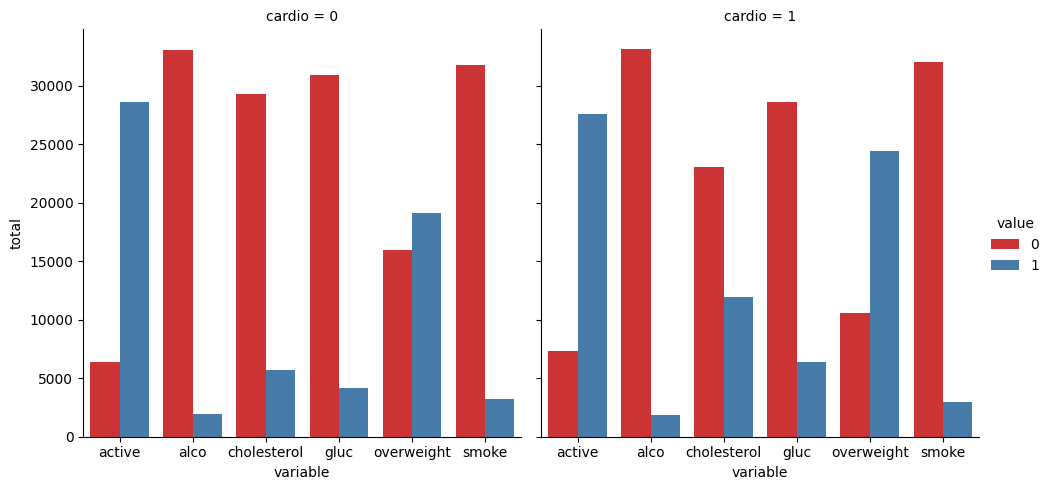

In [42]:
sns.catplot(x = 'variable',
            y = 'total',
            hue = 'value',
            col = 'cardio',
            data = df_categorical,
            kind = 'bar',
            palette='Set1')

In [43]:
df.corr()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight,bmi
id,1.000000,0.003457,0.003154,-0.003038,-0.001830,0.003356,-0.002529,0.005290,0.002844,-0.003699,0.001210,0.003755,0.003799,-0.000832,-0.001377
age,0.003457,1.000000,-0.022609,-0.081515,0.053684,0.020764,0.017647,0.129697,0.088099,-0.047633,-0.029723,-0.009927,0.238159,0.092118,0.085512
gender,0.003154,-0.022609,1.000000,0.498221,0.155115,0.005985,0.015195,-0.034729,-0.018318,0.337664,0.170682,0.005991,0.007953,-0.040700,-0.096409
height,-0.003038,-0.081515,0.498221,1.000000,0.290968,0.005488,0.006150,-0.048532,-0.019400,0.187989,0.094419,-0.006570,-0.010821,-0.115871,-0.290642
weight,-0.001830,0.053684,0.155115,0.290968,1.000000,0.030702,0.043710,0.137981,0.120407,0.067780,0.067113,-0.016867,0.181660,0.616120,0.762009
ap_hi,0.003356,0.020764,0.005985,0.005488,0.030702,1.000000,0.016086,0.024730,0.012886,-0.000922,0.001408,-0.000033,0.054475,0.021255,0.024852
ap_lo,-0.002529,0.017647,0.015195,0.006150,0.043710,0.016086,1.000000,0.026504,0.013747,0.005186,0.010601,0.004780,0.065719,0.030235,0.035345
cholesterol,0.005290,0.129697,-0.034729,-0.048532,0.137981,0.024730,0.026504,1.000000,0.383252,0.017839,0.043610,0.005911,0.205536,0.133545,0.140979
gluc,0.002844,0.088099,-0.018318,-0.019400,0.120407,0.012886,0.013747,0.383252,1.000000,0.002087,0.020606,-0.009061,0.090876,0.095970,0.113098
smoke,-0.003699,-0.047633,0.337664,0.187989,0.067780,-0.000922,0.005186,0.017839,0.002087,1.000000,0.340094,0.025858,-0.015486,-0.001314,-0.027215
